**OLA RIDE INSIGHTS PROJECT**

***1. PROBLEM STATEMENTS***

The rise of ride-sharing platforms has transformed urban mobility, offering convenience and affordability to millions of users. OLA, a leading ride-hailing service, generates vast amounts of data related to ride bookings, driver availability, fare calculations, and customer preferences. However, deriving actionable insights from this data remains a challenge. To enhance operational efficiency, improve customer satisfaction, and optimize business strategies, this project focuses on analyzing OLA’s ride-sharing data. By leveraging data analytics, visualization techniques, and interactive applications, the goal is to extract meaningful insights that can drive data-informed decisions. The project will involve cleaning and processing raw ride data, performing exploratory data analysis (EDA), developing a dynamic Power BI dashboard, and creating a Streamlit-based web application to present key findings in an interactive and user-friendly manner.

***2. PROJECT GOALS***
*    **To examine ride-sharing information**
      
      Gain valuable insights from OLA ride data to comprehend customer behavior, booking trends, and operational patterns.
*   **To carry out preprocessing and data cleaning**

     By addressing missing values, fixing inconsistencies, and getting the dataset ready for analysis, you can guarantee data quality.
*   **To perform EDA, or exploratory data analysis**

     Examine ride data, including peak hours, travel distances, cancellations, and ratings, to find trends, patterns, and connections.
*   **To create SQL queries that are optimized**

    Get and examine important business data, such as income, consumer activity, cancellations, and successful reservations.
*   **To use Power BI to create interactive dashboards**

    Use KPIs and dynamic charts to visualize insights for improved business comprehension and decision-making.
*   **To develop a web application using Streamlit**
    
    For easy access, create an interactive interface that shows insights, SQL outputs, and embedded dashboards.
*   **To obtain practical business insights**

    Find ways to enhance client happiness, pricing tactics, and driver allocation to aid in decision-making.
*   **To improve the effectiveness of operations**

    Utilize data-driven conclusions to enhance service performance, minimize cancellations, and optimize ride distribution.
*   **To successfully convey insights**
    
    Share findings with stakeholders using documentation, narrative, and clear visualizations.

**GitHub Link**

https://github.com/pinudas26/OLA_Ride_Insights


***3. DESCRIPTION OF THE DATASET***

The dataset includes ride-level statistics with characteristics such as:
1.   Date
2.   Time
1.   Booking_ID
2.   Booking_Status
1.   Vehicle_Type
2.   Pickup Location
1.   Drop Location
2.   V_TAT (Vehicle Turnaround Time)
1.   C_TAT (Customer Turnaround Time)
2.   Canceled_Rides_by_Customer
1.   Incomplete_Rides
1.   Incomplete_Rides_Reason
1.   Booking_Value
1.   Payment_Method
2.   Ride_Distance
2.   Driver_Ratings
2.   Customer_Rating
2.   Vehicle Images

***4. Step-by-Step Implementation***

**Step 1: Data Loading**

In [ ]:
import pandas as pd

import os

print(os.listdir())

from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("OLA_DataSet.xlsx - July.csv")
df.head()


['.config', 'sample_data']


Saving OLA_DataSet.xlsx - July.csv to OLA_DataSet.xlsx - July.csv


,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22 3:15:00,3:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02 9:02:00,9:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


**Step 2: Data Cleaning**

In [ ]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Handle missing values
df = df.dropna(subset=['Booking_Status'])

# Convert numeric columns
df['Booking_Value'] = pd.to_numeric(df['Booking_Value'], errors='coerce')
df['Ride_Distance'] = pd.to_numeric(df['Ride_Distance'], errors='coerce')

**Step 3: Feature Engineering**

In [ ]:
# Extract day & hour
df['Day'] = df['Date'].dt.day_name()
df['Hour'] = df['Date'].dt.hour

# Create success flag
df['Success'] = df['Booking_Status'].apply(lambda x: 1 if x == 'Completed' else 0)

**Step 4: EXPLORATORY DATA ANALYSIS**

**4.1 Distribution of Booking Status**

In [ ]:
df['Booking_Status'].value_counts()

,count
Booking_Status,
Success,63967
Canceled by Driver,18434
Canceled by Customer,10499
Driver Not Found,10124


**4.2 Analysis of Revenue**

In [ ]:
import pandas as pd
import os

# Check files (important)
print(os.listdir())

from google.colab import files
uploaded = files.upload()




['.config', 'sample_data']


Saving OLA_DataSet.xlsx - July.csv to OLA_DataSet.xlsx - July.csv


In [ ]:
# Load dataset
df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

# Preview
print(df.head())

# Calculations
total_revenue = df['Booking_Value'].sum()
avg_ride_value = df['Booking_Value'].mean()

print("Total Revenue:", total_revenue)
print("Average Ride Value:", avg_ride_value)

                  Date      Time     Booking_ID        Booking_Status  \
0  2024-07-26 14:00:00  14:00:00  CNR7153255142    Canceled by Driver   
1  2024-07-25 22:20:00  22:20:00  CNR2940424040               Success   
2  2024-07-30 19:59:00  19:59:00  CNR2982357879               Success   
3   2024-07-22 3:15:00   3:15:00  CNR2395710036  Canceled by Customer   
4   2024-07-02 9:02:00   9:02:00  CNR1797421769               Success   

  Customer_ID Vehicle_Type Pickup_Location Drop_Location  V_TAT  C_TAT  \
0   CID713523  Prime Sedan     Tumkur Road      RT Nagar    NaN    NaN   
1   CID225428         Bike     Magadi Road       Varthur  203.0   30.0   
2   CID270156    Prime SUV   Sahakar Nagar       Varthur  238.0  130.0   
3   CID581320        eBike      HSR Layout   Vijayanagar    NaN    NaN   
4   CID939555         Mini     Rajajinagar   Chamarajpet  252.0   80.0   

                     Canceled_Rides_by_Customer      Canceled_Rides_by_Driver  \
0                                  

**4.3 Cancellation Analysis**

In [ ]:
import pandas as pd

# Convert columns safely
cols = ['Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(0)

# Calculate
customer_cancel = df['Canceled_Rides_by_Customer'].sum()
driver_cancel = df['Canceled_Rides_by_Driver'].sum()

print("Customer Cancellations:", customer_cancel)
print("Driver Cancellations:", driver_cancel)

Customer Cancellations: 0.0
Driver Cancellations: 0.0


**4.4 Ratings Analysis**

In [ ]:
avg_driver_rating = df['Driver_Ratings'].mean()
avg_customer_rating = df['Customer_Rating'].mean()

**5. DATA VISUALIZATION**

The practice of displaying data in graphical or pictorial form, such as charts, graphs, and maps, is known as data visualization. Compared to raw data, it makes it easier for people to understand patterns, trends, and insights.

Typical kinds include of:
*   Bar charts (comparison)
*   Line graphs (trends over time)
*   Pie charts (proportions)
*   Scatter plots (relationships)

In [2]:
import pandas as pd

import os

print(os.listdir())

from google.colab import files
uploaded = files.upload()


['.config', 'sample_data']


Saving OLA_DataSet.xlsx - July.csv to OLA_DataSet.xlsx - July.csv


In [3]:
# Load dataset
df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

**BOX PLOT**

**1. Box Plot for Booking Value**

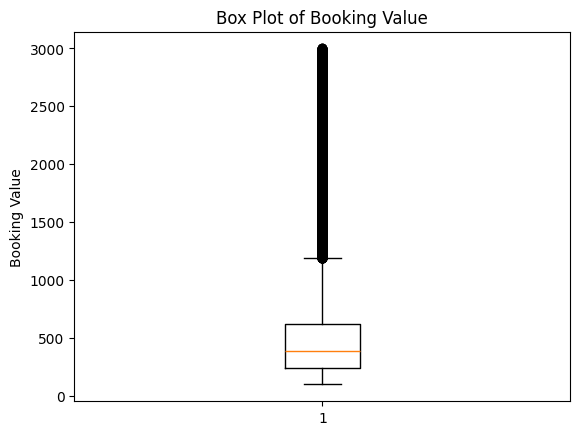

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("OLA_DataSet.xlsx - July.csv")

# Create box plot for Booking Value
plt.figure()
plt.boxplot(data['Booking_Value'].dropna())

# Labels and title
plt.title("Box Plot of Booking Value")
plt.ylabel("Booking Value")

# Show plot
plt.show()

**2. Box Plot for Ride_Distance**

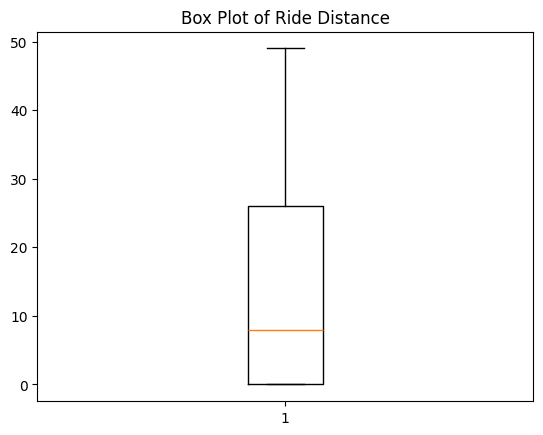

In [5]:
plt.boxplot(data['Ride_Distance'].dropna())
plt.title("Box Plot of Ride Distance")
plt.show()

**3. Box Plot for Driver_Ratings**

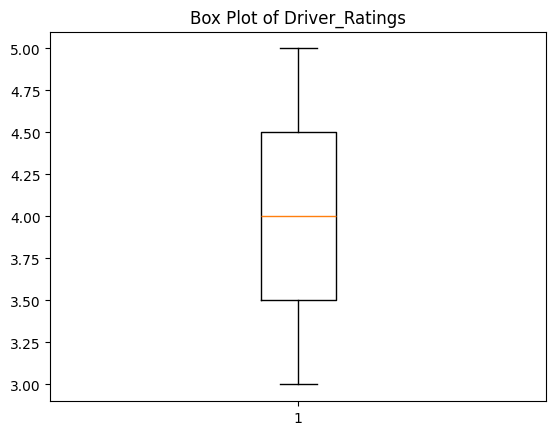

In [6]:
plt.boxplot(data['Driver_Ratings'].dropna())
plt.title("Box Plot of Driver_Ratings")
plt.show()

**4. Box Plot for Customer_Rating**

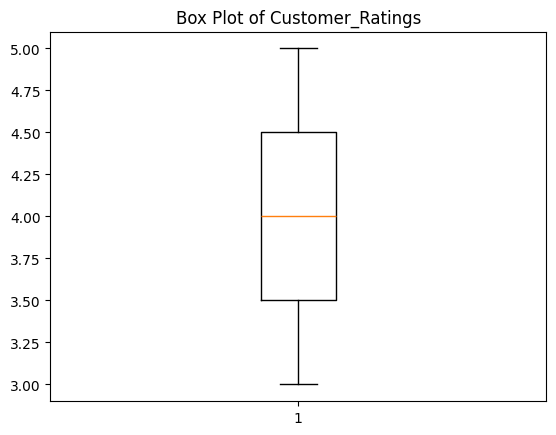

In [7]:
plt.boxplot(data['Customer_Rating'].dropna())
plt.title("Box Plot of Customer_Ratings")
plt.show()

**HISTOGRAM**

A histogram is used to show the distribution of numerical variables by grouping values into ranges (bins).

**1. Histogram for Booking Value**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd

import os

print(os.listdir())

from google.colab import files
uploaded = files.upload()

['.config', 'sample_data']


Saving OLA_DataSet.xlsx - July.csv to OLA_DataSet.xlsx - July.csv


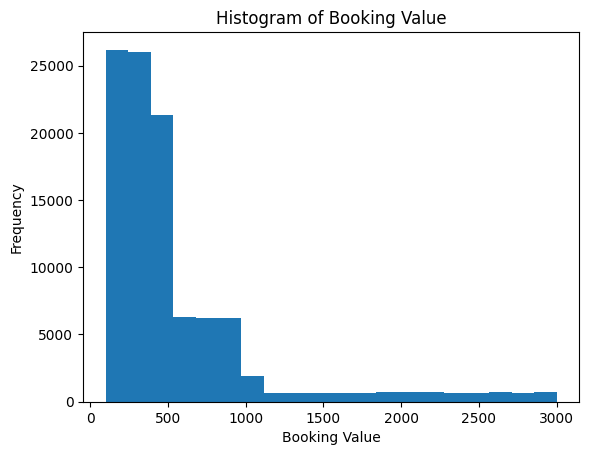

In [3]:
# Load your dataset
df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

# Remove missing values (important for histogram)
data = df['Booking_Value'].dropna()

# Create histogram
plt.figure()
plt.hist(data, bins=20)

# Labels and title
plt.title("Histogram of Booking Value")
plt.xlabel("Booking Value")
plt.ylabel("Frequency")

# Show plot
plt.show()

**2. Histogram for Ride Distance**

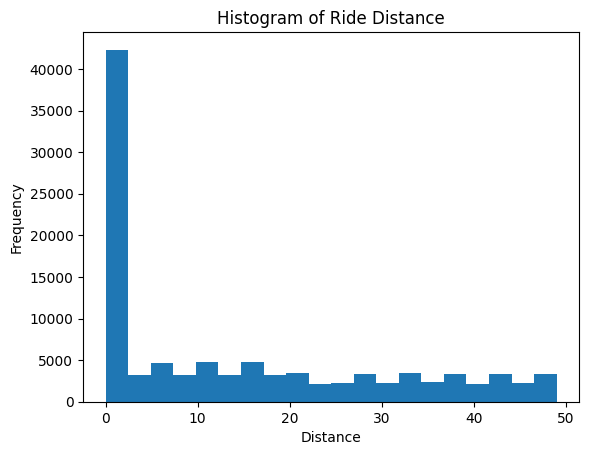

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

data = df['Ride_Distance'].dropna()

plt.figure()
plt.hist(data, bins=20)

plt.title("Histogram of Ride Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

**BAR PLOT**

A bar plot is used to visualize categorical data or discrete numerical variables by showing counts or aggregated values.

**1. Bar Plot for Booking Status**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

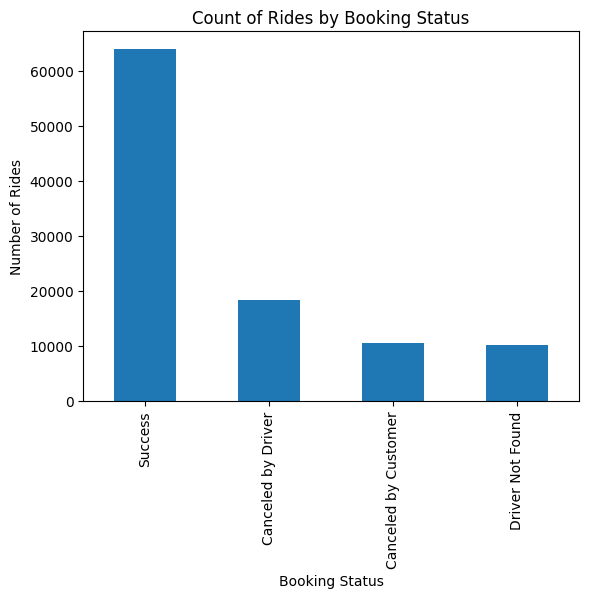

In [6]:
# Count occurrences of each booking status
status_counts = df['Booking_Status'].value_counts()

# Create bar plot
plt.figure()
status_counts.plot(kind='bar')

# Labels and title
plt.title("Count of Rides by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Rides")

# Show plot
plt.show()

**2. Bar Plot for Vehicle Type Distribution**

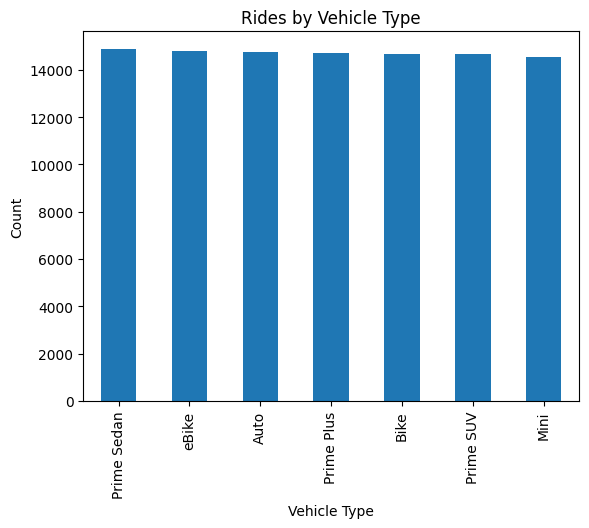

In [7]:
df['Vehicle_Type'].value_counts().plot(kind='bar')
plt.title("Rides by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()

**3. Bar Plot for Payment Method Distribution**

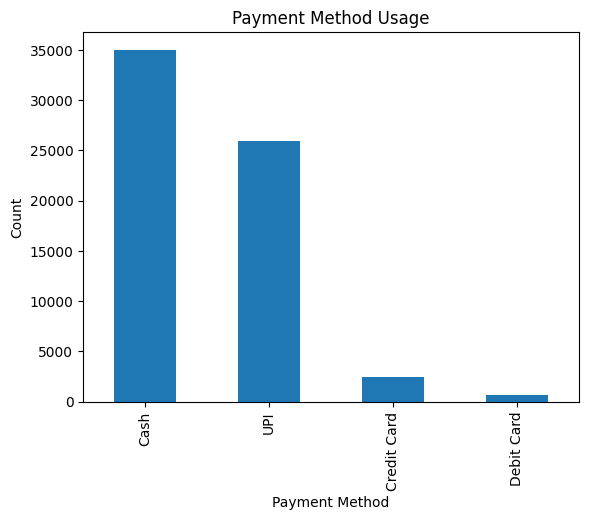

In [8]:
df['Payment_Method'].value_counts().plot(kind='bar')
plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

**PIE CHART**

The percentage share of each category in a dataset is displayed using a pie chart.

**1. Pie Chart of Booking_Status**

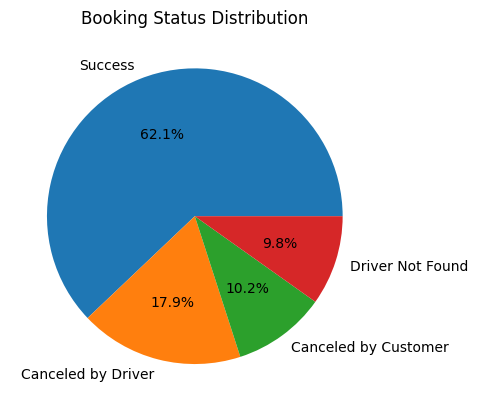

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

# Count values for pie chart
status_counts = df['Booking_Status'].value_counts()

# Create pie chart
plt.figure()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title("Booking Status Distribution")

# Show chart
plt.show()

**Pair Plot**

A Pair Plot is used to visualize relationships between multiple numerical variables at once. It shows:
*  Scatter plots between every pair of variables
*  Distribution (histogram/KDE) on the diagonal

In [18]:
pip install pandas seaborn matplotlib

In [19]:
import pandas as pd

df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

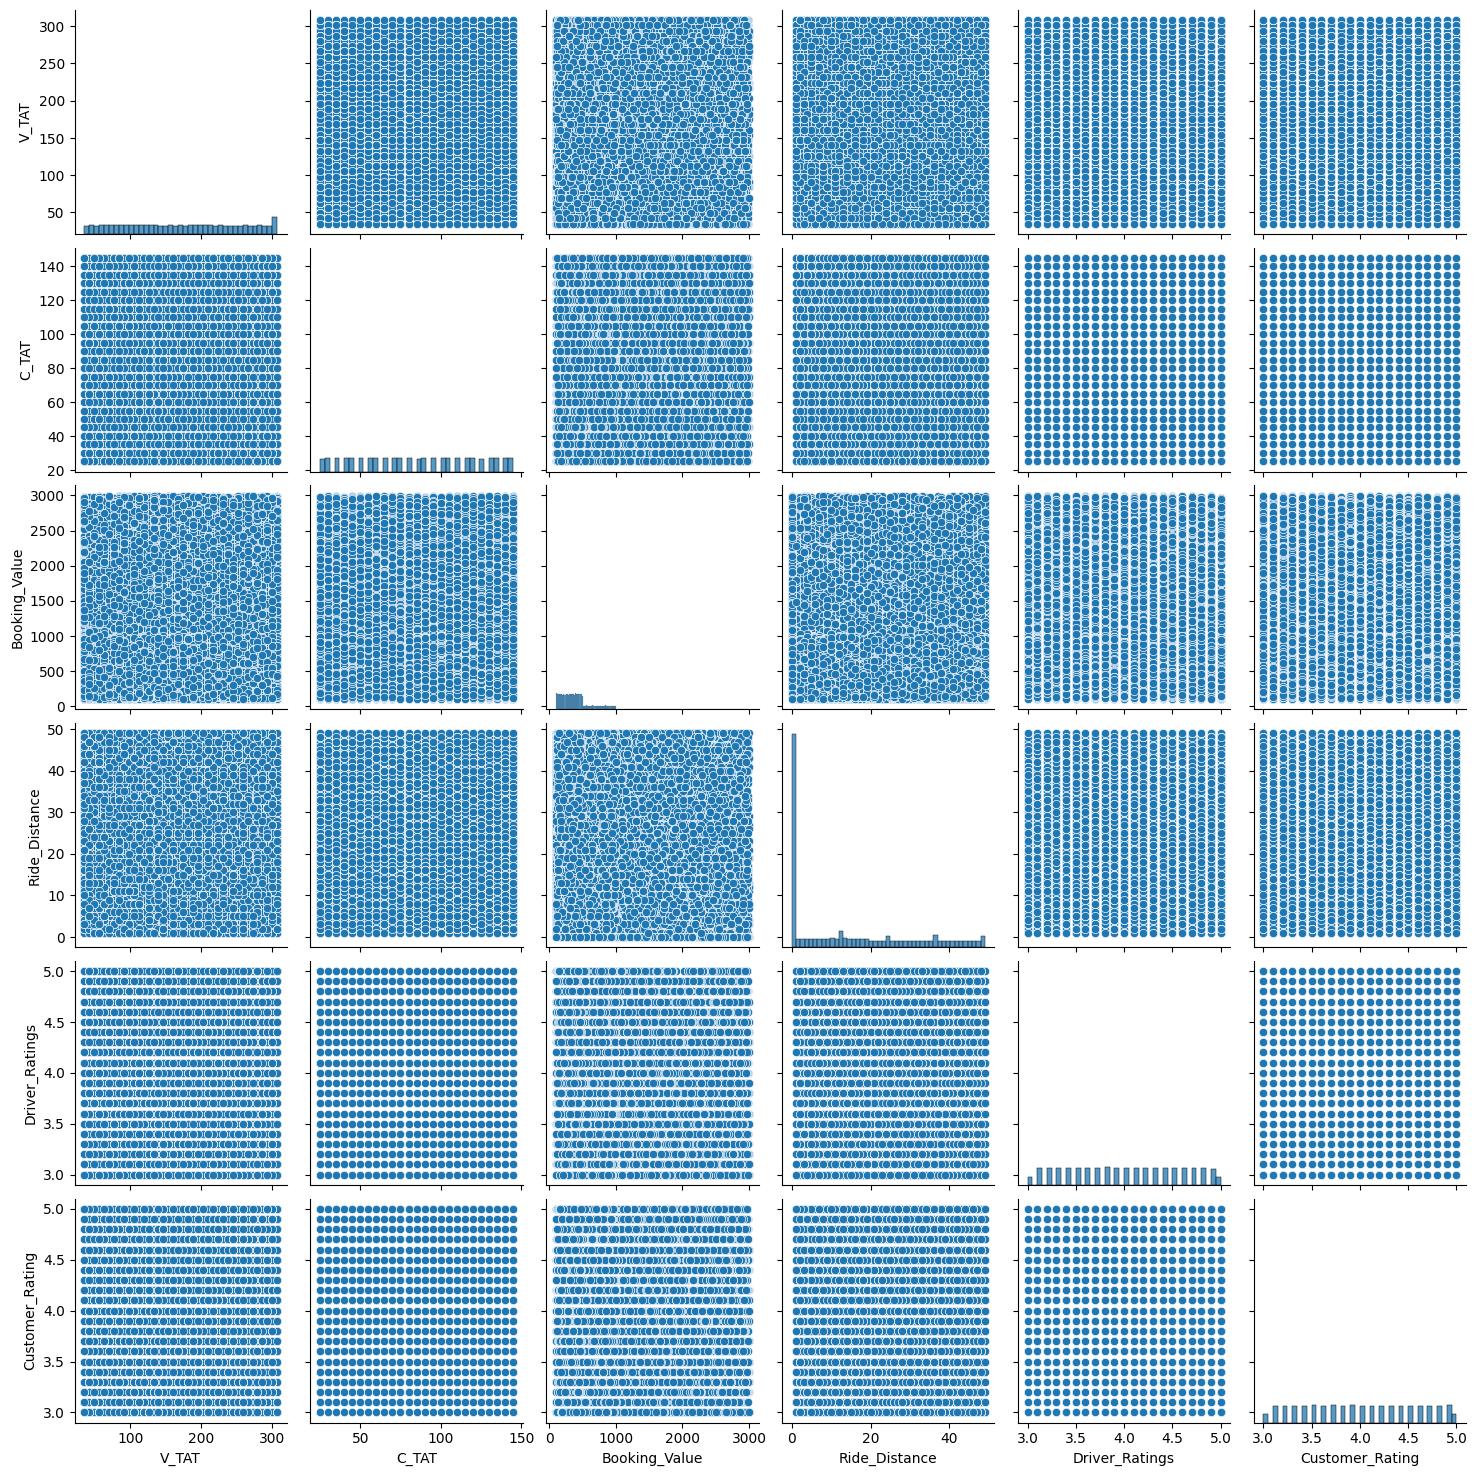

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(numeric_df)
plt.show()

**Correlation Heatmap**

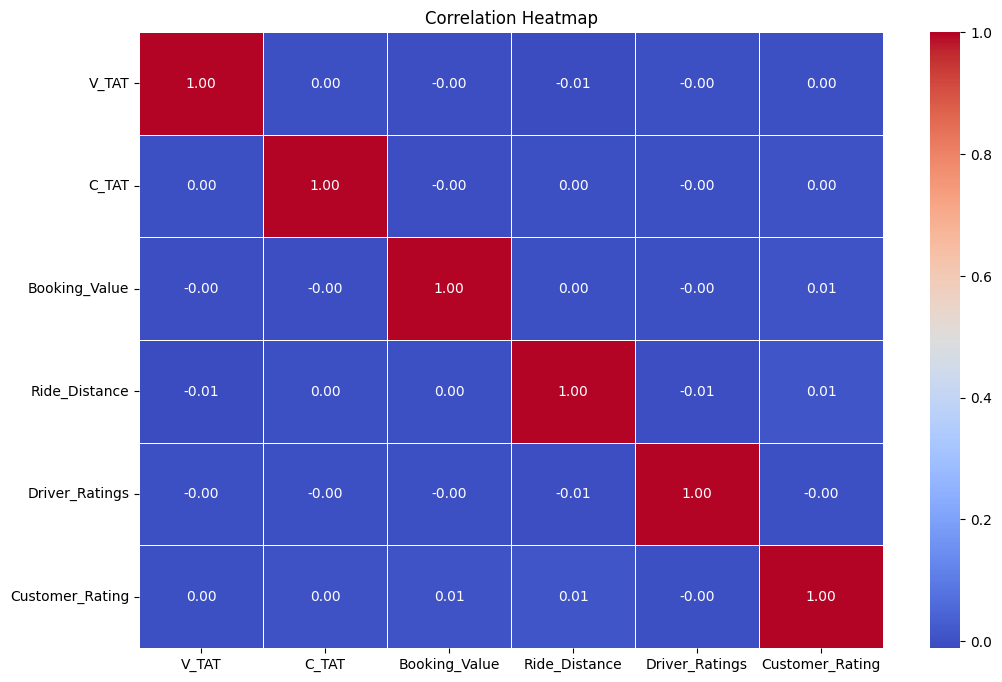

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("OLA_DataSet.xlsx - July.csv")

# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()


**6. RESULT & INSIGHTS**
1.   **Important Findings**
*   The majority of rides are finished, but there are a lot of cancellations.
*   Operational inefficiency is demonstrated by driver cancellations compared to customer cancellations.
*   Commute times are when reservations are most popular.
*   Increased booking value due to longer rides
*   Ratings show that the quality of the services is generally good.

2.   **Business Insights**
*   Enhance the distribution of drivers during rush hours
*   Use incentives to lower cancellations
*   Pay attention to areas with strong demand.
*   Enhance drivers with poor ratings


**6. FINAL RESULT**
*   Trends in ride demand
*   Distribution of revenue
*   Patterns of cancellation
*   Driver and customer performance
*   Bottlenecks in operations

**7. FUTURE SCOPE**
*   Use machine learning models to forecast ride demand
*   Optimize driver allocation
*   Integrate real-time tracking
*   Analysis of dynamic pricing
*   Customer segmentation

**8. CONCLUSION**

This study shows how ride data may be converted into useful insights by using:
*   Python (Data Analysis)
*   Power BI (Visualization)

It enhances:
*   Efficiency of operations
*   Client contentment
*   Optimization of revenue